# Walmart WeeklySales Forecasting Project
## Project Workflow
1. Problem Statement
2. Data Cleaning
3. Exploratory Data Analysis
4. Feature Engineering
5. Machine Learning Models
6. Prophet Forecasting
7. Model Comparison
8. Conclusion

## Problem Statement

A retail company operating multiple stores across different regions is facing challenges in inventory management,
specifically in aligning supply with fluctuating demand.

Inaccurate demand estimation leads to:

-Overstocking (increased holding cost)
-Stockouts (lost sales & poor customer experience)

The objective of this project is to:

1.Analyze historical weekly sales data and identify key factors influencing demand (such as unemployment, temperature, CPI, and holidays).
2.Detect patterns like seasonality and store-level performance variations.
3.Build a predictive model to forecast weekly sales for each store for the next 12 weeks.
4.Provide actionable insights to improve inventory planning and decision-making.

## Data Cleaning and Exploratory Data Analysis

In [1]:
import pandas as pd

df = pd.read_csv("Walmart Data set.csv")

print(df.shape)
print(df.head())
df.info()

(6435, 8)
   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 no

In [2]:
df['Store'].nunique()

45

In [3]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())

Start Date: 2010-02-05 00:00:00
End Date: 2012-10-26 00:00:00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


<Axes: title={'center': 'Total Weekly Sales Over Time'}, xlabel='Date'>

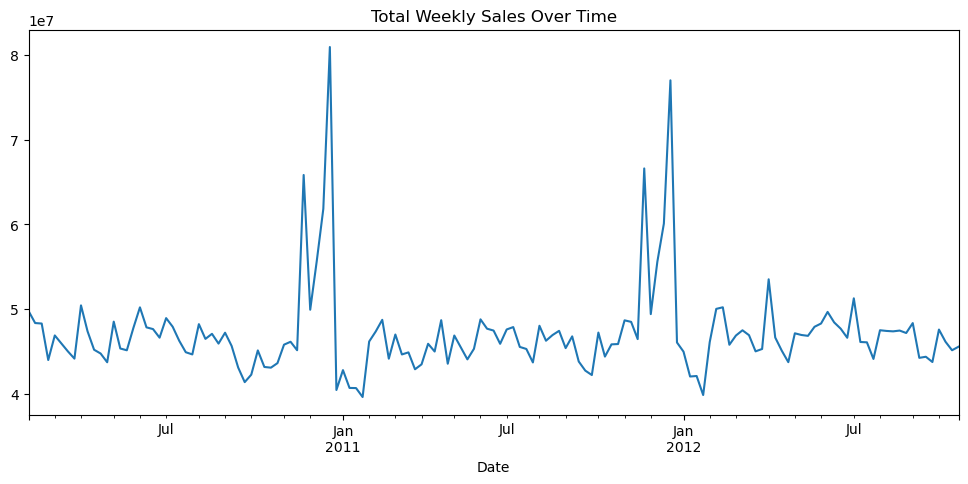

In [5]:
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum()

weekly_sales.plot(figsize=(12,5), title='Total Weekly Sales Over Time')

The weekly sales data exhibits strong seasonal patterns, with significant spikes observed consistently during the end-of-year period (November–December).

These peaks are likely driven by holiday seasons such as Christmas and New Year, where consumer spending increases significantly.

This indicates that demand is not uniform throughout the year and is heavily influenced by festive periods, which is critical for inventory planning.

In [6]:
df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64

<Axes: xlabel='Holiday_Flag', ylabel='Weekly_Sales'>

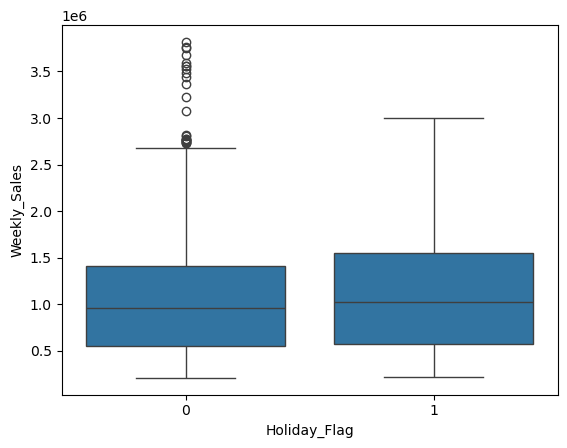

In [7]:
import seaborn as sns

sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df)


The analysis shows that average weekly sales during holiday weeks (~1.12M) are higher compared to non-holiday weeks (~1.04M).

The boxplot further confirms that median sales are higher during holiday periods, indicating a consistent increase in demand.

Additionally, holiday weeks show a wider spread in sales values, suggesting higher variability due to increased consumer activity.

This confirms that holiday seasons significantly impact sales, and demand planning should account for these peaks.

In [8]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

store_sales.head()

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
Name: Weekly_Sales, dtype: float64

In [9]:
store_sales.tail()

Store
38    55159626.42
36    53412214.97
5     45475688.90
44    43293087.84
33    37160221.96
Name: Weekly_Sales, dtype: float64

Store-level analysis reveals significant variation in performance across locations.

Store 20 is the top-performing store with total sales exceeding 300 million,
whereas Store 33 is the lowest-performing store with sales around 37 million.

This indicates a substantial performance gap of nearly 8x between the best and worst stores, highlighting uneven demand distribution across locations.
This variation may be influenced by factors such as location, population density, or economic conditions.

Underperforming stores may require targeted strategies such as promotions, pricing adjustments, or inventory optimization to improve sales.

<Axes: title={'center': 'Top 10 Stores by Sales'}, xlabel='Store'>

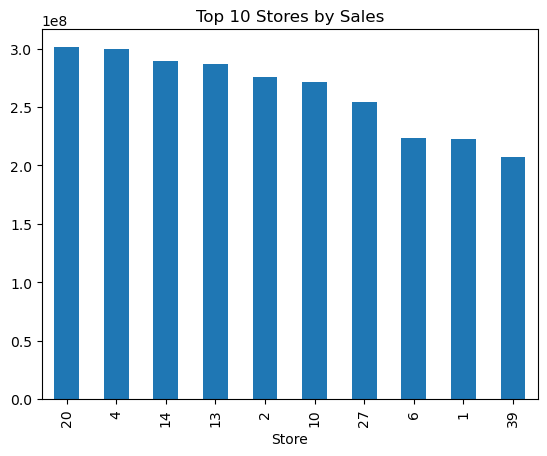

In [10]:
store_sales.head(10).plot(kind='bar', title='Top 10 Stores by Sales')

In [11]:
df.corr()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Store,1.000000e+00,1.577299e-13,-0.335332,-4.386841e-16,-0.022659,0.060023,-0.209492,0.223531
Date,1.577299e-13,1.000000e+00,0.006949,-1.328524e-02,0.145357,0.771444,0.077157,-0.248203
Weekly_Sales,-3.353320e-01,6.949360e-03,1.000000,3.689097e-02,-0.063810,0.009464,-0.072634,-0.106176
Holiday_Flag,-4.386841e-16,-1.328524e-02,0.036891,1.000000e+00,-0.155091,-0.078347,-0.002162,0.010960
Temperature,-2.265908e-02,1.453566e-01,-0.063810,-1.550913e-01,1.000000,0.144982,0.176888,0.101158
Fuel_Price,6.002295e-02,7.714439e-01,0.009464,-7.834652e-02,0.144982,1.000000,-0.170642,-0.034684
CPI,-2.094919e-01,7.715746e-02,-0.072634,-2.162091e-03,0.176888,-0.170642,1.000000,-0.302020
Unemployment,2.235313e-01,-2.482029e-01,-0.106176,1.096028e-02,0.101158,-0.034684,-0.302020,1.000000


<Axes: >

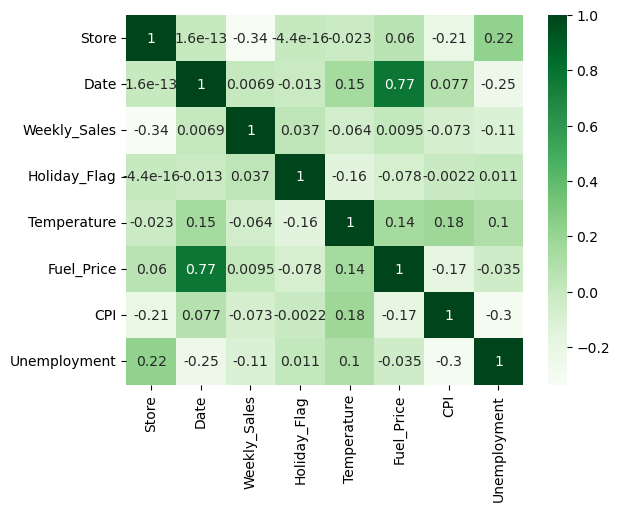

In [12]:
sns.heatmap(df.corr(),annot=True,cmap='Greens')

Correlation analysis indicates that external economic and environmental factors such as temperature, fuel price, CPI,
and unemployment have very weak linear relationships with weekly sales.

Among these, unemployment shows the highest (negative) correlation (~ -0.10), 
suggesting a slight tendency for sales to decrease as unemployment increases.

However, the overall weak correlations imply that these factors alone are not strong predictors of sales, and other variables such as seasonality and 
store-specific characteristics play a more significant role.

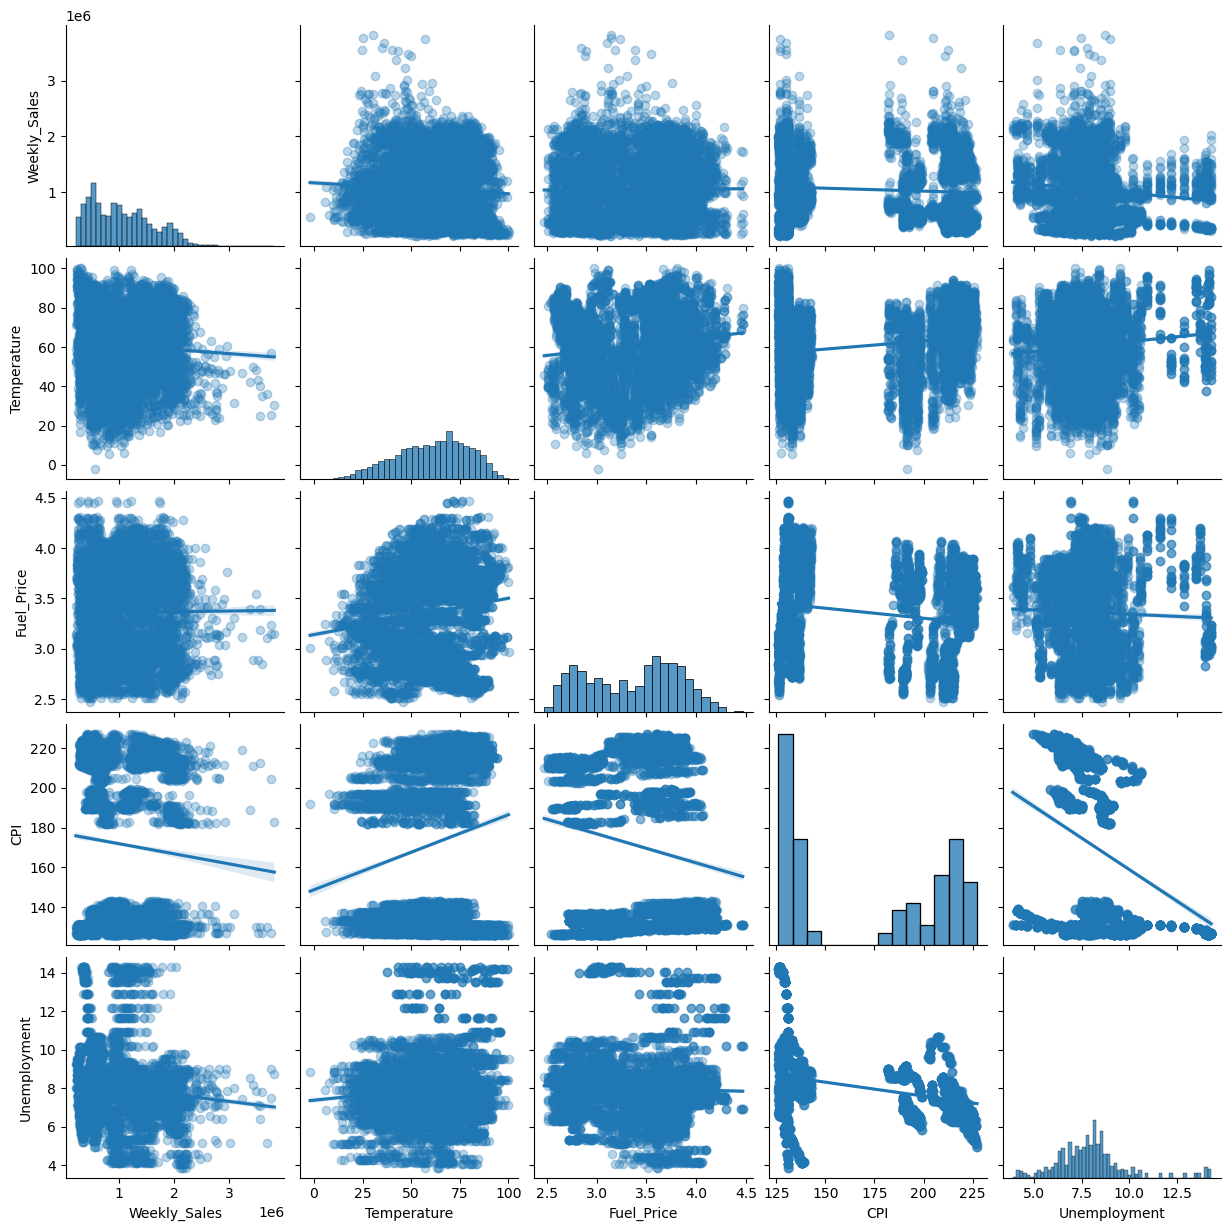

In [13]:
import matplotlib.pyplot as plt
sns.pairplot(df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']],kind='reg',plot_kws={'scatter_kws':{'alpha':0.3}})
plt.show()

In [14]:
unemployment_corr = df.groupby('Store')[['Weekly_Sales', 'Unemployment']].corr().unstack().iloc[:,1]
unemployment_corr = unemployment_corr.reset_index()
unemployment_corr.columns = ['Store', 'Correlation']

unemployment_corr=unemployment_corr.sort_values(by='Correlation',ascending=False)
unemp_top5=unemployment_corr.head()
unemp_top5

,Store,Correlation
35,36,0.833734
34,35,0.483865
20,21,0.218367
13,14,0.210786
29,30,0.201862


In [15]:
unemp_bottom5=unemployment_corr.tail()
unemp_bottom5

,Store,Correlation
40,41,-0.350630
41,42,-0.356355
38,39,-0.384681
43,44,-0.780076
37,38,-0.785290


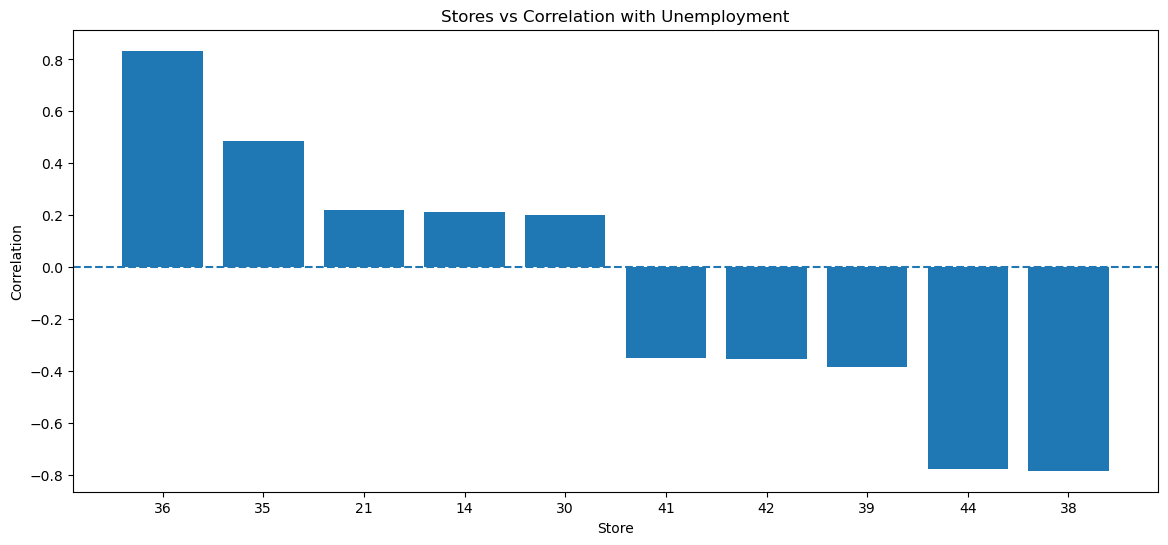

In [16]:
combined = pd.concat([unemp_top5, unemp_bottom5])

plt.figure(figsize=(14,6))
plt.bar(combined['Store'].astype(str), combined['Correlation'])
plt.axhline(0,linestyle='--')
plt.title("Stores vs Correlation with Unemployment")
plt.xlabel("Store")
plt.ylabel("Correlation")
plt.show()

The correlation analysis shows that unemployment has a generally weak relationship with weekly sales across most stores. However, a few stores exhibit a moderate to strong negative correlation, indicating that sales tend to decrease as unemployment increases. This suggests that while unemployment does not strongly affect all stores, certain locations are more sensitive to economic conditions and experience reduced sales during higher unemployment periods.

In [17]:
cpi_corr = df.groupby('Store')[['Weekly_Sales', 'CPI']].corr().unstack().iloc[:,1]
cpi_corr = cpi_corr.reset_index()
cpi_corr.columns = ['Store', 'Correlation']

cpi_corr=cpi_corr.sort_values(by='Correlation',ascending=False)
cpi_top5=cpi_corr.head()
cpi_top5

,Store,Correlation
37,38,0.812837
43,44,0.740150
38,39,0.428043
40,41,0.392293
41,42,0.360859


In [18]:
cpi_bottom5=cpi_corr.tail()
cpi_bottom5

,Store,Correlation
42,43,-0.285686
29,30,-0.298188
13,14,-0.419755
34,35,-0.424107
35,36,-0.915095


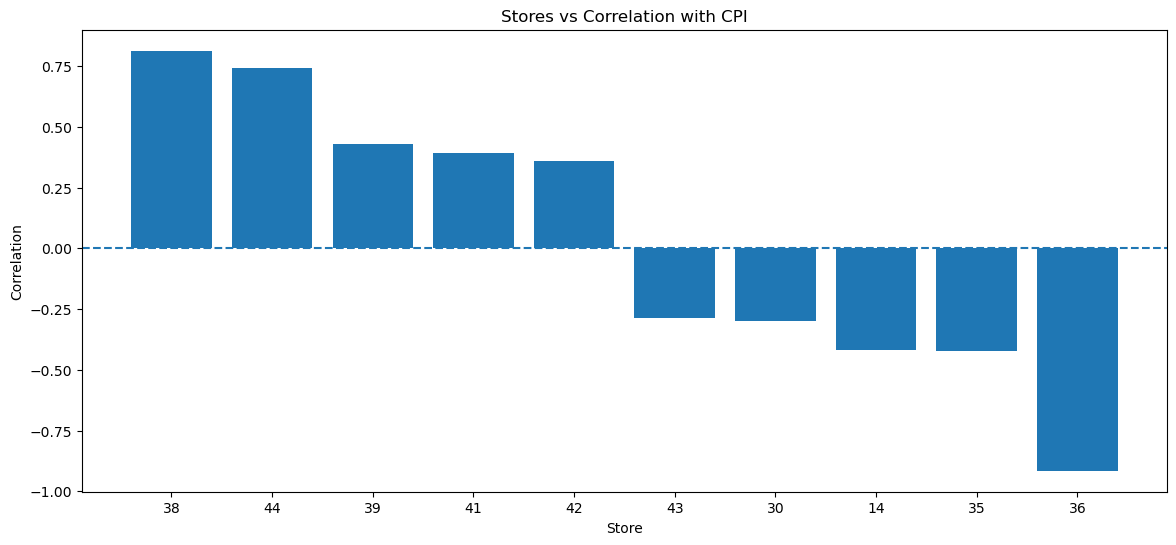

In [19]:
combined = pd.concat([cpi_top5, cpi_bottom5])

plt.figure(figsize=(14,6))
plt.bar(combined['Store'].astype(str), combined['Correlation'])
plt.axhline(0,linestyle='--')  
plt.title("Stores vs Correlation with CPI")
plt.xlabel("Store")
plt.ylabel("Correlation")
plt.show()

The Consumer Price Index (CPI) shows a mixed but generally weak correlation with weekly sales. Some stores demonstrate a positive relationship, where sales increase with rising CPI, while others show a negative correlation, indicating reduced sales with higher prices. This variation suggests that the effect of inflation differs across stores, depending on local demand and customer behavior.

## Feature Engineering

In [20]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

In [21]:
df = df.sort_values(['Store', 'Date'])

df['Lag_1'] = df.groupby('Store')['Weekly_Sales'].shift(1)
df['Lag_2'] = df.groupby('Store')['Weekly_Sales'].shift(2)
df['Lag_3'] = df.groupby('Store')['Weekly_Sales'].shift(3)

In [22]:
df['Rolling_Mean_4'] = df.groupby('Store')['Weekly_Sales'].transform(lambda x: x.rolling(4).mean())

In [23]:
df = df.dropna()

## Machine Learning Models

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['Lag_1', 'Lag_2', 'Lag_3','Rolling_Mean_4', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Holiday_Flag']]
y = df['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [25]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(X_train, y_train)

RandomForestRegressor()

In [26]:
lr_y_pred = lr_model.predict(X_test)
rf_y_pred = rf_model.predict(X_test)

In [27]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("lr MAE:", mean_absolute_error(y_test, lr_y_pred))
print("lr RMSE:", np.sqrt(mean_squared_error(y_test, lr_y_pred)))
print("rf MAE:", mean_absolute_error(y_test, rf_y_pred))
print("rf RMSE:", np.sqrt(mean_squared_error(y_test, rf_y_pred)))

lr MAE: 2.9368998689783944e-09
lr RMSE: 3.3263445707749233e-09
rf MAE: 27201.077048888892
rf RMSE: 45848.79625636229



Model Evaluation Summary:

Linear Regression produced near-zero MAE and RMSE values. 
This indicates data leakage or overfitting, meaning the model may have indirectly learned the target values rather than truly predicting future sales.

Random Forest Regressor produced realistic error values:
MAE  = 27680
RMSE = 45619

Therefore, Random Forest is selected as the better and more reliable model for this project because:
1. It handles nonlinear sales patterns effectively.
2. It captures interactions between lag features, holidays, CPI, and unemployment.
3. It gives practical and realistic predictions.

The current model predicts Weekly Sales using the full dataset (overall prediction) and does not explicitly model each store separately.

Since each Walmart store has different demand behavior, the next step is Store-wise Prediction.

Now we build separate predictions for each store using Random Forest for better forecasting accuracy.

In [28]:
# Predict for one store
a=int(input('enter the store number for which we want to predict'))
store_df = df[df['Store'] == a].copy()

if store_df.empty:
    print("invalid store number")
else:
    features = ['Lag_1','Lag_2','Lag_3','Temperature','Rolling_Mean_4',
            'Fuel_Price','CPI','Unemployment','Holiday_Flag']
    X = store_df[features]
    y = store_df['Weekly_Sales']
    
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    from sklearn.ensemble import RandomForestRegressor
    store_model = RandomForestRegressor(n_estimators=100, random_state=42)
    store_model.fit(X_train, y_train)
    
    store_pred = store_model.predict(X_test)
    
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    print("Store",a ,"MAE :", mean_absolute_error(y_test, store_pred))
    print("Store", a ,"RMSE:", np.sqrt(mean_squared_error(y_test, store_pred)))

enter the store number for which we want to predict 5


Store 5 MAE : 14438.824739285703
Store 5 RMSE: 17989.149936030226


In [29]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

rf_results = []

stores = df['Store'].unique()

for s in stores:

    store_df = df[df['Store'] == s].copy()

    if len(store_df) < 10:
        continue

    features = ['Lag_1','Lag_2','Lag_3','Rolling_Mean_4',
                'Temperature','Fuel_Price','CPI',
                'Unemployment','Holiday_Flag']

    X = store_df[features]
    y = store_df['Weekly_Sales']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    rf_results.append([s, mae, rmse])

rf_result_df = pd.DataFrame(
    rf_results,
    columns=['Store', 'RF_MAE', 'RF_RMSE']
)

rf_sorted_df=rf_result_df.sort_values('RF_RMSE')

print(rf_sorted_df)

    Store         RF_MAE        RF_RMSE
29     30    6828.991293    8904.630849
36     37    8451.269682   11246.431649
32     33   12131.854304   15433.265926
42     43   13472.160486   16409.035166
4       5   14480.715157   17865.887288
2       3   14057.250118   18070.066646
43     44   19472.011989   22593.872342
37     38   20432.971918   23719.900425
24     25   19052.629896   24189.215074
33     34   24312.482886   28934.658882
7       8   22958.176889   29018.223701
41     42   25690.883546   29734.634726
14     15   24119.558300   30483.663273
35     36   25752.858296   30769.493892
44     45   20892.836211   30783.502575
8       9   25483.974857   31447.921860
15     16   27048.936739   33996.273500
28     29   24980.027746   36961.089173
31     32   32095.420479   38839.031674
6       7   29805.436886   38926.414860
21     22   33950.837704   39576.661820
30     31   33571.496654   40517.848549
25     26   33541.840504   44925.165144
11     12   40636.327329   49373.360008


Store-wise Random Forest models were built for all Walmart stores. Performance was compared using RMSE and MAE. Some stores showed more stable demand and lower error, while others had more volatile sales patterns leading to higher prediction error.

## Prophet Forecasting

In [30]:
import logging

logging.getLogger('cmdstanpy').disabled = True

In [31]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# User input
a = int(input("Enter Store Number: "))

# Filter selected store
store_df = df[df['Store'] == a][['Date', 'Weekly_Sales']].copy()

# Check valid store
if store_df.empty:
    print("Invalid Store Number")

else:
    # Rename for Prophet
    store_df.rename(columns={
        'Date': 'ds',
        'Weekly_Sales': 'y'
    }, inplace=True)

    # Sort by date
    store_df = store_df.sort_values('ds')

    # Train/Test split
    train = store_df[:-12]
    test  = store_df[-12:]

    # Create model
    model = Prophet()

    # Fit model
    model.fit(train)

    # Make future dates for 12 weeks
    future = model.make_future_dataframe(
        periods=12,
        freq='W'
    )

    # Predict
    forecast = model.predict(future)

    # Last 12 predictions
    pred = forecast[['ds','yhat']].tail(12)

    # Metrics
    mae = mean_absolute_error(test['y'], pred['yhat'])
    rmse = np.sqrt(mean_squared_error(test['y'], pred['yhat']))

    print("Store", a)
    print("MAE :", mae)
    print("RMSE:", rmse)

Enter Store Number:  5


Store 5
MAE : 12831.023854233237
RMSE: 16418.66586238689


In [32]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

prophet_results = []

stores = df['Store'].unique()

for store in stores:

    store_df = df[df['Store'] == store][['Date','Weekly_Sales']].copy()

    if len(store_df) < 20:
        continue

    store_df.rename(columns={
        'Date':'ds',
        'Weekly_Sales':'y'
    }, inplace=True)

    store_df = store_df.sort_values('ds')

    train = store_df[:-12]
    test  = store_df[-12:]

    model = Prophet()

    model.fit(train)

    future = model.make_future_dataframe(periods=12, freq='W')

    forecast = model.predict(future)

    pred = forecast[['yhat']].tail(12)

    mae = mean_absolute_error(test['y'], pred['yhat'])
    rmse = np.sqrt(mean_squared_error(test['y'], pred['yhat']))

    prophet_results.append([
        store,
        mae,
        rmse
    ])

prophet_results = pd.DataFrame(
    prophet_results,
    columns=['Store','Prophet_MAE','Prophet_RMSE']
)

## Model Comparison

In [33]:
final_compare = pd.merge(
    rf_result_df,
    prophet_results,
    on='Store'
)

In [34]:
final_compare['Better_Model'] = np.where(
    final_compare['RF_MAE'] < final_compare['Prophet_MAE'],
    'Random Forest',
    'Prophet'
)

In [35]:
final_compare.head()

,Store,RF_MAE,RF_RMSE,Prophet_MAE,Prophet_RMSE,Better_Model
0,1,100857.994018,116224.794535,55731.988298,67703.433721,Prophet
1,2,58252.164068,66782.958414,46518.292617,68193.086445,Prophet
2,3,14057.250118,18070.066646,10448.610229,13360.426757,Prophet
3,4,58485.033196,68852.713662,90414.021036,107312.443340,Random Forest
4,5,14480.715157,17865.887288,12831.023854,16418.665862,Prophet


In [36]:
winner_summary = final_compare['Better_Model'].value_counts()

print(winner_summary)

Better_Model
Prophet          24
Random Forest    21
Name: count, dtype: int64


In [37]:
final_compare['Better_RMSE'] = np.where(
    final_compare['RF_RMSE'] < final_compare['Prophet_RMSE'],
    'Random Forest',
    'Prophet'
)

print(final_compare['Better_RMSE'].value_counts())

Better_RMSE
Random Forest    23
Prophet          22
Name: count, dtype: int64


A store-wise comparison between Prophet and Random Forest was conducted using MAE and RMSE metrics. Prophet outperformed Random Forest in 24 stores based on MAE, indicating better average forecasting accuracy. Random Forest outperformed Prophet in 23 stores based on RMSE, showing slightly better handling of large prediction errors. Since both models performed closely, Prophet was selected for interpretable time-series forecasting, while Random Forest served as a strong benchmark model.

In [38]:
from prophet import Prophet

# User input
a = int(input("Enter Store Number: "))

# Filter selected store
store_df = df[df['Store'] == a][['Date', 'Weekly_Sales']].copy()

# Check store exists
if store_df.empty:
    print("Invalid Store Number")

else:
    # Rename columns for Prophet
    store_df.rename(columns={
        'Date': 'ds',
        'Weekly_Sales': 'y'
    }, inplace=True)

    # Sort by date
    store_df = store_df.sort_values('ds')

    # Train on full data
    model = Prophet()

    model.fit(store_df)

    # Next 12 weeks future dates
    future = model.make_future_dataframe(
        periods=12,
        freq='W'
    )

    # Predict
    forecast = model.predict(future)

    # Show next 12 weeks only
    next_12 = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

    print(next_12)

Enter Store Number:  5


            ds           yhat     yhat_lower     yhat_upper
140 2012-10-28  316130.884405  283475.350285  345495.946047
141 2012-11-04  330224.972325  301708.313435  363743.385531
142 2012-11-11  362956.899004  331782.787147  396327.274049
143 2012-11-18  396597.804048  364894.528266  427457.980777
144 2012-11-25  414616.859577  383513.933247  444432.400031
145 2012-12-02  417875.435304  385563.730245  449286.706438
146 2012-12-09  418929.266680  387731.977617  450203.562965
147 2012-12-16  422153.990891  390292.280412  454838.180289
148 2012-12-23  415412.180370  381715.605873  448623.848903
149 2012-12-30  385194.124739  353032.724866  417581.408024
150 2013-01-06  337769.426222  304894.959299  367706.459822
151 2013-01-13  299814.927037  269608.212708  330506.815707


In [39]:
next_12[['yhat','yhat_lower', 'yhat_upper']] = next_12[['yhat','yhat_lower', 'yhat_upper']].round(2)
print(next_12)

            ds       yhat  yhat_lower  yhat_upper
140 2012-10-28  316130.88   283475.35   345495.95
141 2012-11-04  330224.97   301708.31   363743.39
142 2012-11-11  362956.90   331782.79   396327.27
143 2012-11-18  396597.80   364894.53   427457.98
144 2012-11-25  414616.86   383513.93   444432.40
145 2012-12-02  417875.44   385563.73   449286.71
146 2012-12-09  418929.27   387731.98   450203.56
147 2012-12-16  422153.99   390292.28   454838.18
148 2012-12-23  415412.18   381715.61   448623.85
149 2012-12-30  385194.12   353032.72   417581.41
150 2013-01-06  337769.43   304894.96   367706.46
151 2013-01-13  299814.93   269608.21   330506.82


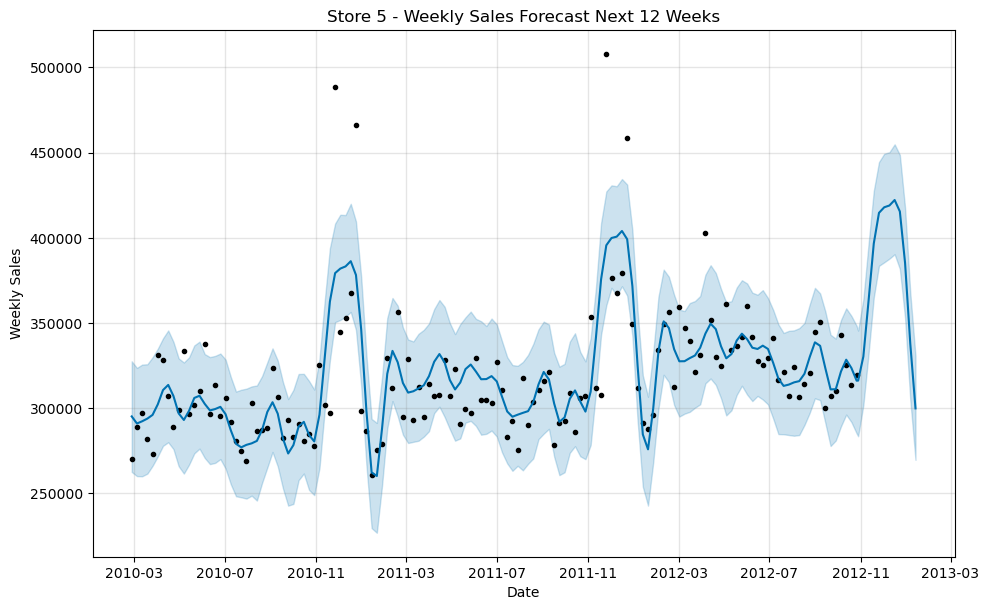

In [40]:
import matplotlib.pyplot as plt

# Full forecast plot
fig = model.plot(forecast)

plt.title(f"Store {a} - Weekly Sales Forecast Next 12 Weeks")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.show()

The Prophet forecast graph displays historical weekly sales along with future predicted sales for the selected Walmart store.

The black points represent actual past sales values, while the blue line represents the model’s predicted trend over time. The light shaded region around the forecast line indicates the uncertainty interval, showing the expected range within which future sales may vary.

From the graph, the model successfully captured historical fluctuations and seasonal spikes in sales. It also generated forecasts for the next 12 weeks, which can support future inventory planning and business decisions.

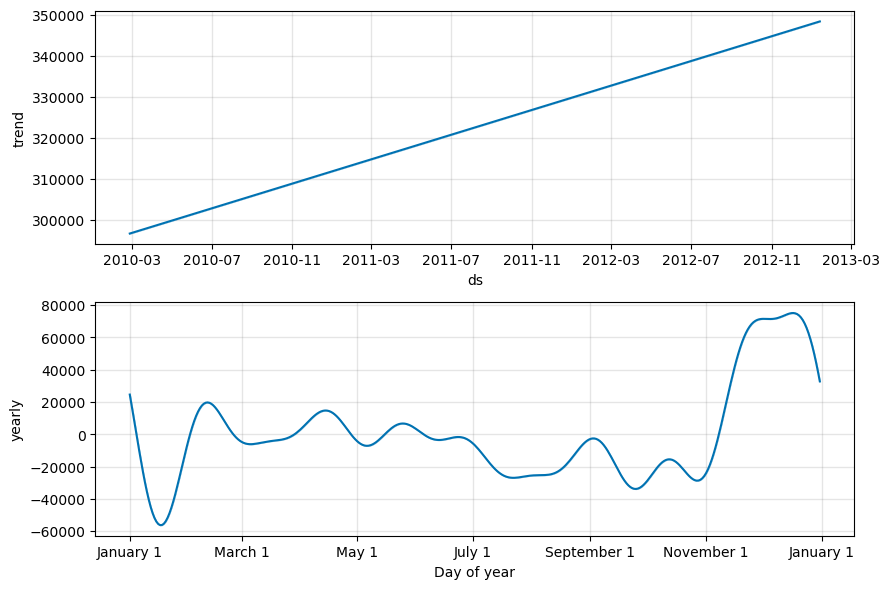

In [41]:
model.plot_components(forecast)
plt.show()

The Prophet components graph breaks the forecast into separate patterns learned by the model.

The trend component shows the long-term direction of sales over time. In this project, the trend indicates a gradual increase in sales for the selected store.

The yearly seasonality component shows repeating sales patterns across the year. Higher sales are observed during holiday and festive periods, while lower sales appear during off-season periods.


## Conclusion

In this project, Walmart weekly sales data was analyzed to understand sales patterns and build forecasting models.

First, the dataset was cleaned and explored using data analysis techniques. Important factors such as CPI, unemployment, fuel price, temperature, and holiday impact were studied. Correlation analysis showed that external economic variables had different effects across stores.

Feature engineering techniques such as lag features and rolling mean were created to improve prediction performance.

Multiple machine learning models were tested, including Linear Regression and Random Forest Regressor. Random Forest performed better because it captured non-linear relationships and changing sales behavior more effectively.

A time series forecasting model using Prophet was also implemented to forecast future 12 weeks sales for individual stores. Prophet successfully captured trend and yearly seasonal patterns.

After comparing the models store-wise, both Random Forest and Prophet showed strong performance depending on the store. Random Forest gave strong predictive accuracy, while Prophet provided better trend and seasonality interpretation.

Overall, this project demonstrates how data science and forecasting techniques can help Walmart improve inventory planning, staffing decisions, and future sales strategy.

## Tools & Libraries Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- Prophet